# Segmentación de Clientes usando Clustering

## Proyecto Final — Aprendizaje de Máquina

### Objetivo

El objetivo de este proyecto es segmentar clientes de una tienda online según sus patrones de compra utilizando técnicas de aprendizaje no supervisado (clustering).

A partir del historial transaccional de compras, se buscará identificar diferentes perfiles de clientes para comprender mejor su comportamiento y apoyar estrategias de marketing, retención y fidelización.

### Dataset

Se utilizará el dataset “Online Retail”, el cual contiene transacciones realizadas por una tienda online del Reino Unido entre 2010 y 2011.

##1. Librerias

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

pd.set_option('display.max_columns', None)

##2. Carga del Dataset

In [ ]:
df = pd.read_excel('/content/online_retail_II.xlsx')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


##3. Exploracion inicial

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


###Valores faltantes

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


##4. Entendamos los datos

Países con Mayor Número de Compras

Se analiza desde qué países provienen la mayoría de las transacciones.

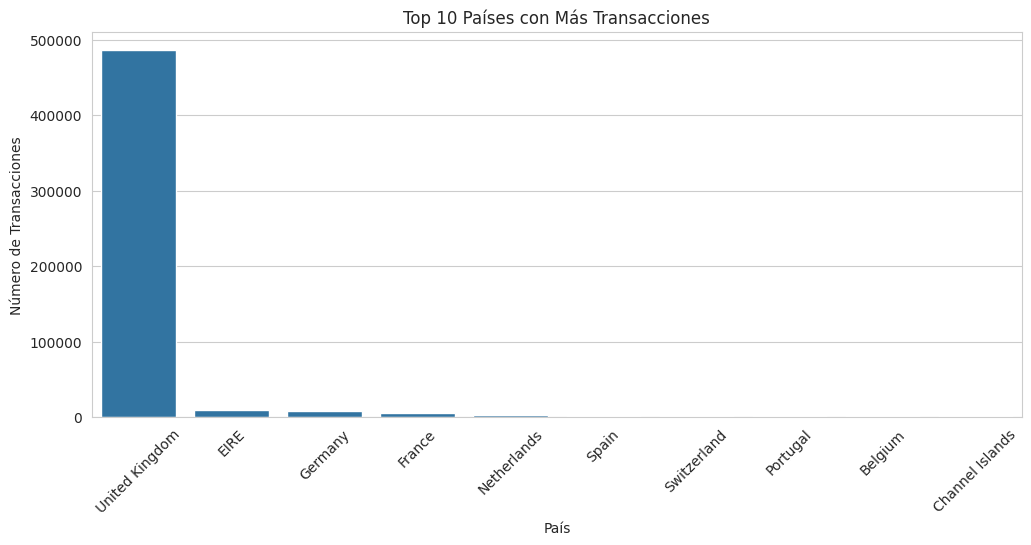

In [ ]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.xticks(rotation=45)

plt.title('Top 10 Países con Más Transacciones')

plt.xlabel('País')
plt.ylabel('Número de Transacciones')

plt.show()

###Compras por mes

Porque ayuda a entender:
comportamiento temporal,
temporadas,
actividad comercial.

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

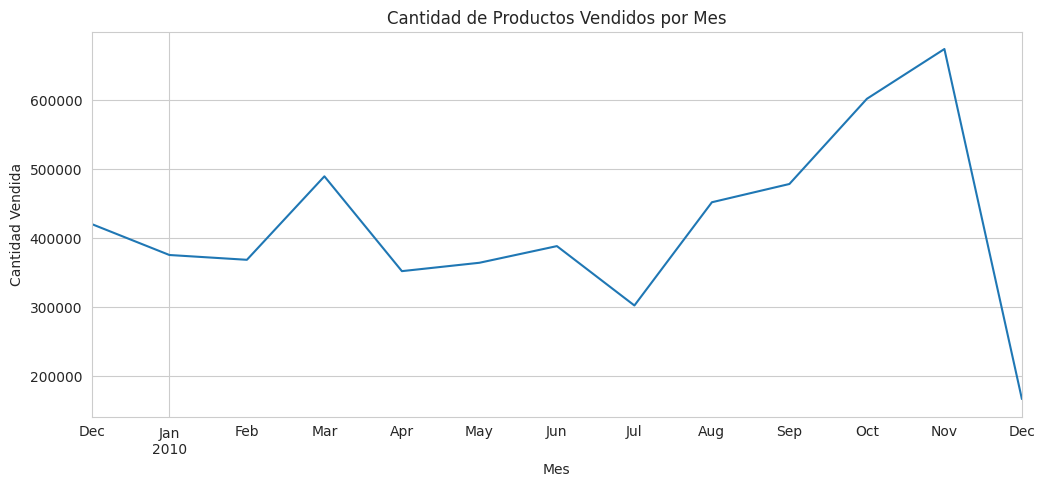

In [ ]:
monthly_sales = df.groupby('YearMonth')['Quantity'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Cantidad de Productos Vendidos por Mes')

plt.xlabel('Mes')
plt.ylabel('Cantidad Vendida')

plt.show()

### Construccion de Total Price

Se crea una nueva variable que representa el valor monetario total de cada transacción.

Esta es útil porque:
representa dinero,
y nos ayuda a entender el comportamiento de compra.

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['Price']

df[['Quantity', 'Price', 'TotalPrice']].head()

,Quantity,Price,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


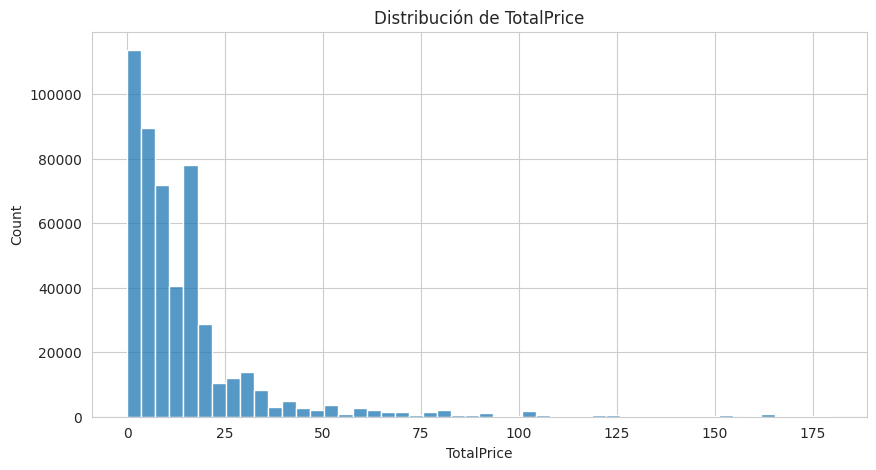

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[
        (df['TotalPrice'] > 0) &
        (df['TotalPrice'] < 180)
    ]['TotalPrice'],
    bins=50
)

plt.title('Distribución de TotalPrice')

plt.xlabel('TotalPrice')

plt.show()

La mayoría de las transacciones corresponden a compras de bajo valor, mientras que existen pocas compras de alto valor.

Significa que muchos clientes hacen compras pequeñas, pocos clientes hacen compras grandes.

---
##5. Limpieza y preparacion de datos

Antes de construir los perfiles de clientes, es necesario limpiar el dataset para eliminar registros inválidos o inconsistentes.

En esta etapa:
- se eliminarán clientes sin identificador,
- devoluciones o cancelaciones,
- y valores negativos o inválidos.

###Eliminar CustomerID nulos

In [ ]:
df['Customer ID'].isnull().sum()

np.int64(107927)

In [ ]:
df = df.dropna(subset=['Customer ID'])

In [ ]:
df['Customer ID'].isnull().sum()

np.int64(0)

Los registros sin CustomerID fueron eliminados debido a que no es posible construir perfiles de clientes sin un identificador único

###Revisar cantidades negativas

Las cantidades negativas representan devoluciones o cancelaciones de compras.

In [ ]:
(df['Quantity'] < 0).sum()

np.int64(9839)

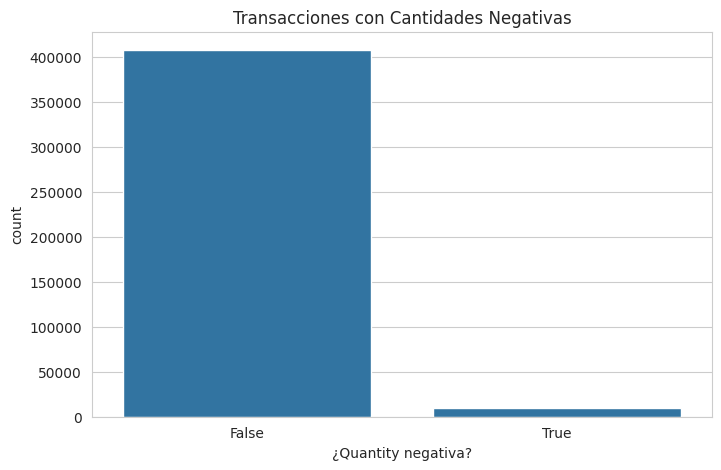

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=(df['Quantity'] < 0)
)

plt.title('Transacciones con Cantidades Negativas')

plt.xlabel('¿Quantity negativa?')

plt.show()

In [ ]:
df = df[df['Quantity'] > 0]

###Eliminamos precios negativos

In [ ]:
(df['Price'] <= 0).sum()

np.int64(31)

In [ ]:
df = df[df['Price'] > 0]

In [ ]:
df.shape

(407664, 10)

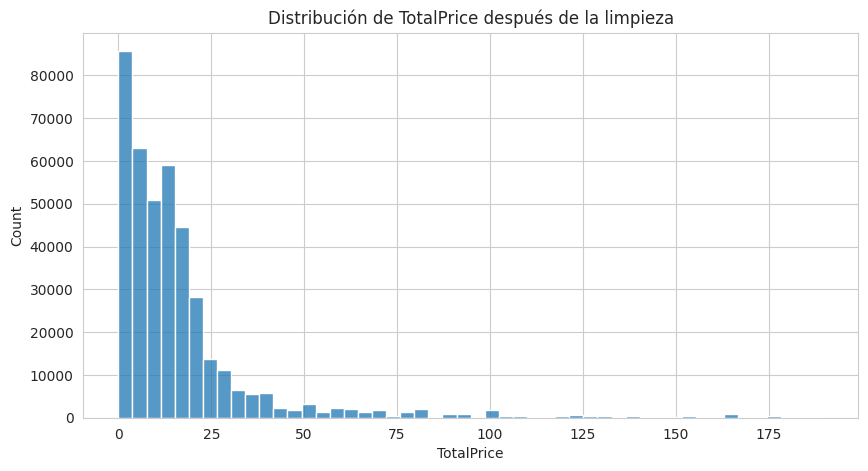

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df['TotalPrice'] < 190]['TotalPrice'],
    bins=50
)

plt.title('Distribución de TotalPrice después de la limpieza')

plt.show()

##6. Construccion de perfiles de clientes

Aqui comenzamos a pensar mas en como se comporta el cliente que en transacciones indivicuales.

Para representar el comportamiento de compra de cada cliente, se utilizará la metodología RFM:

- Recency: días desde la última compra.
- Frequency: número de compras realizadas.
- Monetary: dinero total gastado.

Estas variables permiten resumir el comportamiento de cada cliente y son muy utilizadas en segmentación de clientes.

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2010-12-10 20:01:00')

La fecha de referencia se utiliza para calcular cuántos días han pasado desde la última compra de cada cliente.

###Construir tabla RFM

Cada fila ahora representa un cliente y no una transacción individual.

Las variables RFM resumen: qué tan reciente fue la última compra, cuántas compras realizó, y cuánto dinero gastó.

In [ ]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


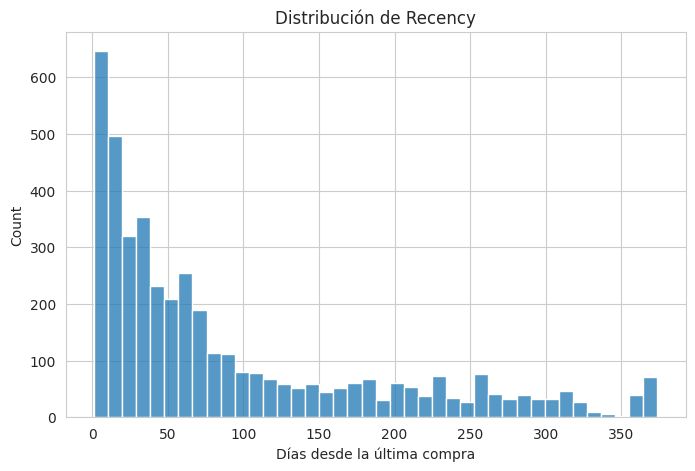

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Recency'],
    bins=40
)

plt.title('Distribución de Recency')

plt.xlabel('Días desde la última compra')

plt.show()

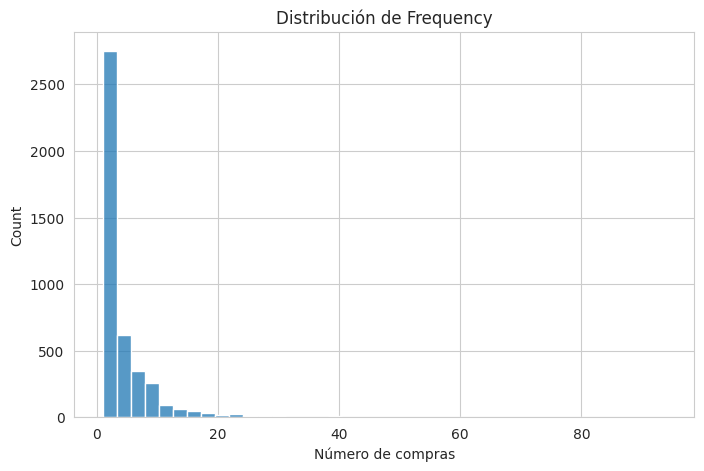

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm[rfm['Frequency'] < 100]['Frequency'],
    bins=40
)

plt.title('Distribución de Frequency')

plt.xlabel('Número de compras')

plt.show()

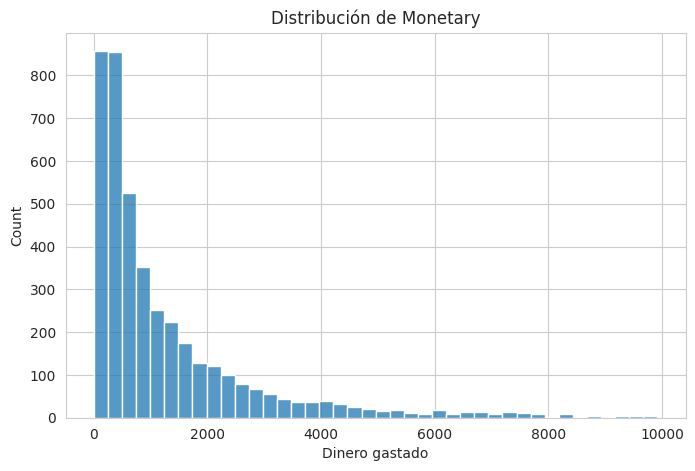

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm[rfm['Monetary'] < 10000]['Monetary'],
    bins=40
)

plt.title('Distribución de Monetary')

plt.xlabel('Dinero gastado')

plt.show()

### Relación entre Variables RFM

Se analiza la relación entre las variables de comportamiento de compra.

Frequency y Monetary estan correlacionadas.
Clientes que compran mas suelen gastar mas. Por lo que podemos comenzar a notar perfiles naturales.

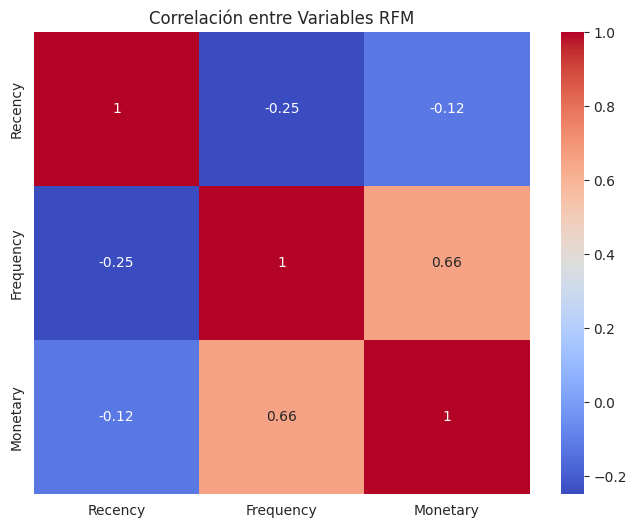

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    rfm[['Recency', 'Frequency', 'Monetary']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlación entre Variables RFM')

plt.show()

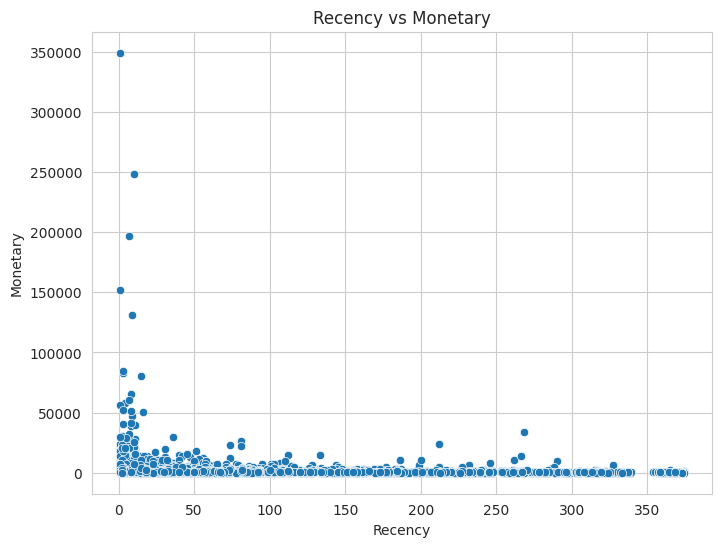

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary'
)

plt.title('Recency vs Monetary')

plt.show()

In [ ]:
#Cada puntito en la grafica representa un customer
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


##7. Preparacion para hacer el Clustering

Aquí vamos a:
seleccionar variables,
escalarlas,
y empezar a buscar patrones automáticamente.

### Escalado de Variables

Las variables RFM tienen escalas muy diferentes.

Por ejemplo:
- Monetary puede alcanzar miles de unidades monetarias,
- mientras que Recency se mide en días.

Por eso, es necesario escalar las variables para evitar que una sola domine el proceso de clustering.

In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.762299,0.801087,-0.187961
12347.0,-0.910402,-0.300603,-0.081329
12348.0,-0.177305,-0.423013,-0.204868
12349.0,-0.497389,-0.178193,0.069883
12351.0,-0.827799,-0.423013,-0.196031


In [ ]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.312000e+03,4.312000e+03,4.312000e+03
mean,5.602610e-17,5.932175e-17,-2.306957e-17
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-9.310522e-01,-4.230129e-01,-2.294610e-01
25%,-7.555219e-01,-4.230129e-01,-1.952388e-01
50%,-3.941361e-01,-3.006029e-01,-1.505835e-01
75%,4.628645e-01,6.662716e-02,-3.647250e-02
max,2.920288e+00,2.454863e+01,3.894297e+01


Ahora buscamos patrones visuales dentro de las variables que ya tenemos para buscar si hay relaciones entre variables para explorar posibles agrupamientos naturales.

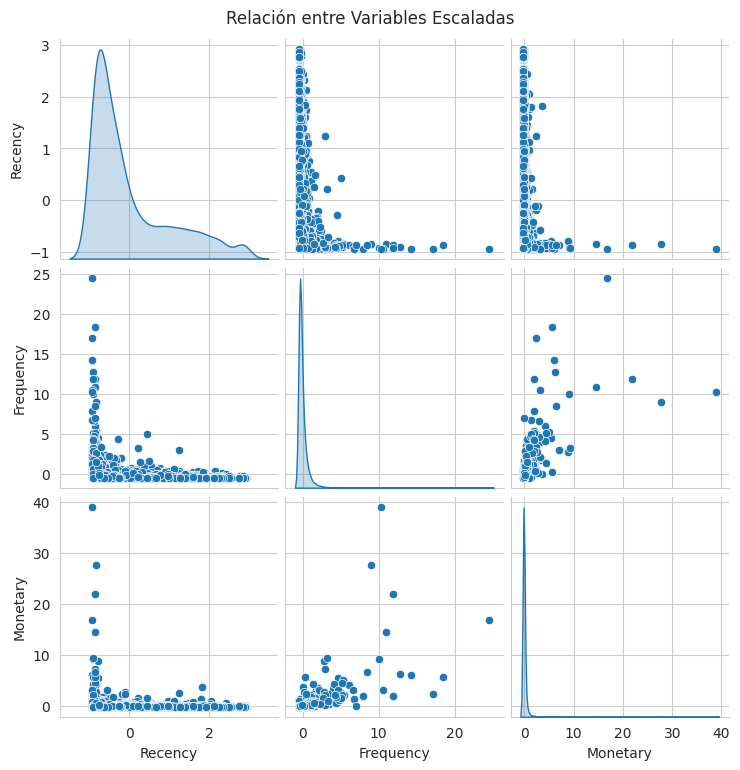

In [ ]:
sns.pairplot(
    rfm_scaled,
    diag_kind='kde'
)

plt.suptitle(
    'Relación entre Variables Escaladas',
    y=1.02
)

plt.show()

###Elegir el numero de clusters

Para esto utilizamos una metrica interna de el metodo del codo para identificar el numero adecuado de clusters observando como disminuye la variacion interna del modelo

Aquí buscamos el punto donde la mejora deja de ser fuerte,
o sea el “codo”.
Y eso ayuda a elegir k.

In [ ]:
inertia = []

K = range(2,11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

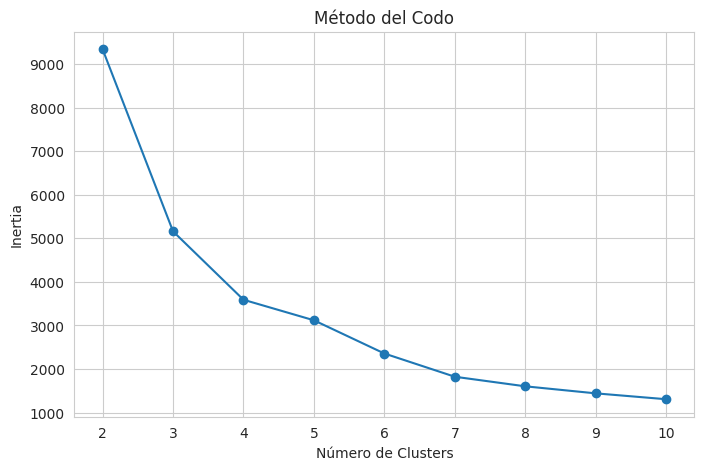

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.title('Método del Codo')

plt.xlabel('Número de Clusters')

plt.ylabel('Inertia')

plt.show()

Luego utilizamos la Silhouette Score

que esta metrica evalua que tan bien separados estan los clusters entre si

In [ ]:
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

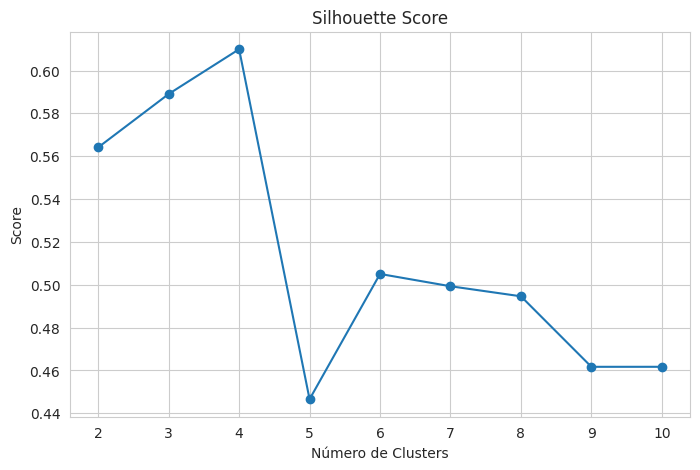

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')

plt.xlabel('Número de Clusters')

plt.ylabel('Score')

plt.show()

entre mas cerca esten del 1, significa que estan muy bien separados.

##Por lo que k = 4

---
##8. Entrenar el modelo

Aquí es donde:
los clusters aparecen y empezamos a ver perfiles reales

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()
#Aqui el modelo le asigno a cada cliente un grupo
#segun las similitudes de su comportamiento

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,165,11,372.86,1
12347.0,3,2,1323.32,0
12348.0,74,1,222.16,0
12349.0,43,3,2671.14,0
12351.0,11,1,300.93,0


###Pairplot con clusters

Se visualizan las relaciones entre variables RFM utilizando colores para representar los clusters generados por K-Means.


- Monetary muy alto = clientes VIP
- Frequency baja = clientes ocasionales
- Recency baja = clientes inactivos

Text(0.5, 1.02, 'Clusters de Clientes')

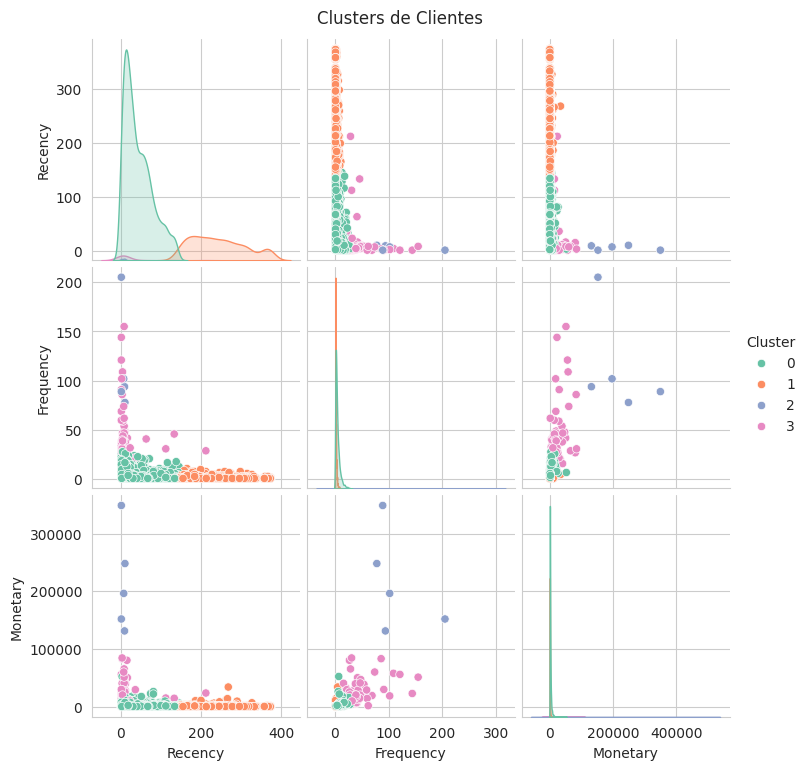

In [ ]:
sns.pairplot(
    rfm,
    vars=['Recency', 'Frequency', 'Monetary'],
    hue='Cluster',
    palette='Set2'
)

plt.suptitle(
    'Clusters de Clientes',
    y=1.02
)

# plt.show()

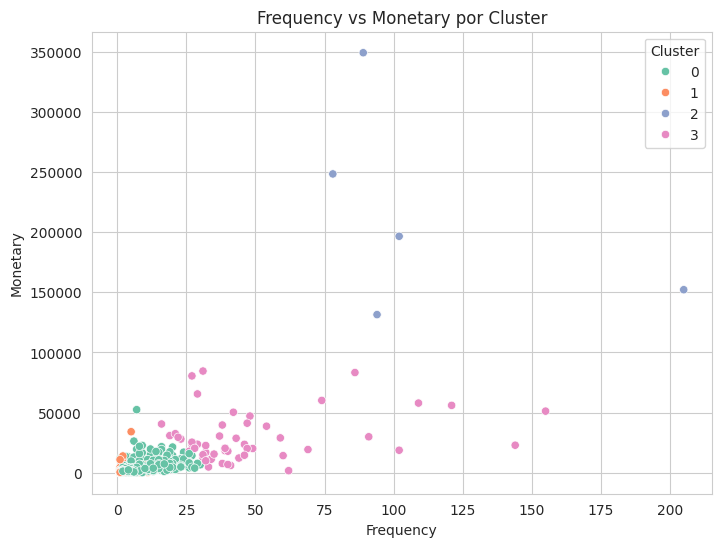

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Frequency vs Monetary por Cluster')

plt.show()

Aqui podemos observar que normalmente los clientes VIP parecen ser los del cluster 2, pues es alto el monetary y la frecuencia tambien. Asi como podemos ver que los que estan mas cerca del 0 son los clientes pequeños.

---

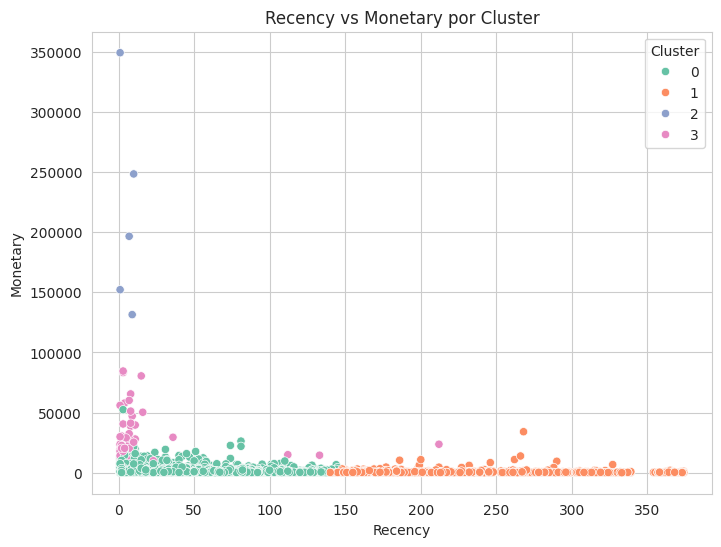

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Recency vs Monetary por Cluster')

plt.show()

Aqui podemos observar que los clientes del cluster 2, no compraron recientemente mas sus compras fueron grandes, en cambio los del cluster 1 tuvieron compras pequeñas pero varias recientes.

---

###Perfil promedio de los clusters

Se calcula el promedio de las variables RFM para cada cluster con el fin de interpretar el comportamiento de cada segmento.

In [ ]:
cluster_summary = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.996882,4.469598,1743.129790
1,242.976122,1.659981,596.884493
2,5.600000,113.600000,215543.670000
3,15.433962,48.547170,29040.181566


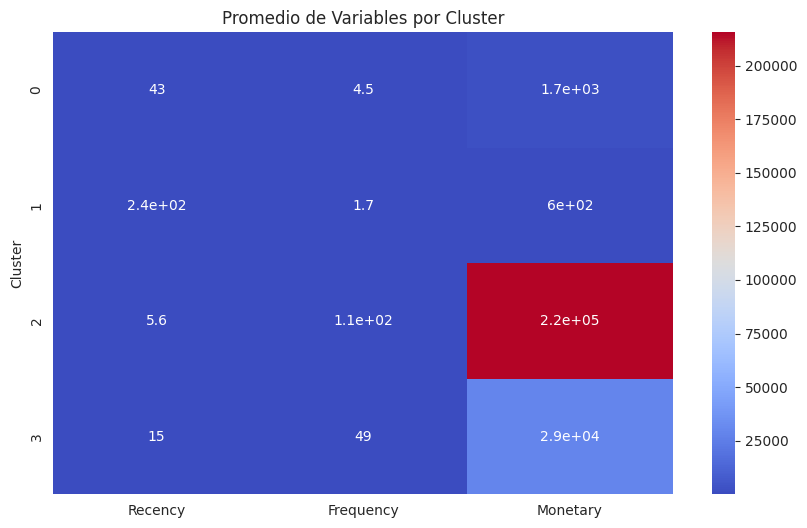

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap='coolwarm'
)

plt.title('Promedio de Variables por Cluster')

plt.show()

##9. Conclusiones

Se aplicó un modelo de clustering utilizando K-Means para segmentar clientes de una tienda online a partir de su comportamiento de compra.

A través de las variables RFM (Recency, Frequency y Monetary), fue posible representar el comportamiento de cada cliente y separar diferentes perfiles de consumo.

El análisis exploratorio permitió identificar patrones importantes en los datos, como:
- alta concentración de compras pequeñas,
- presencia de clientes con gastos significativamente mayores,
- y diferencias claras en frecuencia de compra.

Despues, mediante técnicas de escalado y clustering, se pudieron identificar grupos de clientes con comportamientos similares.

Algunos clusters corresponden a:
- clientes frecuentes y de alto valor,
- clientes ocasionales,
- y clientes con baja actividad o inactivos.

Esta segmentación puede ser utilizada para:
- campañas de marketing personalizadas,
- estrategias de retención,
- programas de fidelización,
- y análisis de clientes VIP.

Finalmente, se demuestra cómo las técnicas de aprendizaje no supervisado pueden utilizarse para descubrir patrones ocultos en datos reales y apoyar la toma de decisiones en negocios.